In [39]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"


In [40]:
order=pd.read_csv(r"..\cleanData\clean_order.csv", sep=";")
loan=pd.read_csv(r"..\cleanData\clean_loan.csv", sep=";")
account=pd.read_csv(r"..\cleanData\clean_account.csv", sep=";")
card=pd.read_csv(r"..\cleanData\clean_card.csv", sep=";")
client=pd.read_csv(r"..\cleanData\clean_client.csv", sep=";")
disp=pd.read_csv(r"..\cleanData\clean_disp.csv", sep=";")
district=pd.read_csv(r"..\cleanData\clean_district.csv", sep=";")


In [41]:
# Prepare dates for windowing
loan['date'] = pd.to_datetime(loan['date'])
trans['date'] = pd.to_datetime(trans['date'])

trans_features_list = []

# Pre-index order_agg for fast O(1) lookup inside loop
order_payment_map = (
    order_agg.set_index('account_id')['order_amount_loan_payment'].to_dict()
    if 'order_agg' in locals()
    else {}
)

for idx, loan_row in loan.iterrows():
  acc_id = loan_row['account_id']
  loan_id = loan_row['loan_id']
  loan_date = loan_row['date']
  loan_payment_installment = loan_row['payments']
  six_months_prior = loan_date - pd.DateOffset(months=6)

  # Get pre-existing order debt payment for this account (default to 0 if none)
  existing_uver_order = order_payment_map.get(acc_id, 0)

  # Filter transactions strictly prior to loan origination within 6-month window
  sub_trans = trans[
      (trans['account_id'] == acc_id)
      & (trans['date'] < loan_date)
      & (trans['date'] >= six_months_prior)
  ]

  # All transactions prior to loan (for last_balance)
  all_prior_trans = trans[
      (trans['account_id'] == acc_id) & (trans['date'] < loan_date)
  ]

  if len(sub_trans) > 0:
    min_bal_6m = sub_trans['balance'].min()
    mean_bal_6m = sub_trans['balance'].mean()
    std_bal_6m = sub_trans['balance'].std()
    total_inflow_6m = sub_trans[sub_trans['type'] == 'PRIJEM']['amount'].sum()
    total_outflow_6m = sub_trans[sub_trans['type'] == 'VYBER']['amount'].sum()
    freq_neg_balance = sub_trans[sub_trans['balance'] < 0]['date'].nunique()

    # Sanction interest payment check
    sanction_interest = sub_trans[
        sub_trans['k_symbol'].astype(str).str.strip().str.upper()
        == 'SANKC. UROK'
    ]['amount'].sum()

    avg_monthly_withdraws = total_outflow_6m / 6.0
    avg_monthly_deposits = total_inflow_6m / 6.0
    avg_tx_amount = sub_trans['amount'].mean()
    tx_per_month = len(sub_trans) / 6.0
  else:
    min_bal_6m = mean_bal_6m = std_bal_6m = 0
    total_inflow_6m = total_outflow_6m = 0
    freq_neg_balance = sanction_interest = 0
    avg_monthly_withdraws = avg_monthly_deposits = 0
    avg_tx_amount = tx_per_month = 0

  # Calculate Debt-to-Income ratio (using monthly deposit inflow as income proxy)
  # Prevent division by zero with max(..., 1.0)
  income_proxy = max(avg_monthly_deposits, 1.0)
  total_monthly_debt = loan_payment_installment + existing_uver_order
  debt_to_income = total_monthly_debt / income_proxy

  last_balance = (
      all_prior_trans.sort_values('date').iloc[-1]['balance']
      if len(all_prior_trans) > 0
      else 0
  )

  trans_features_list.append({
      'loan_id': loan_id,
      'account_id': acc_id,
      'min_balance_6m': min_bal_6m,
      'mean_balance_6m': mean_bal_6m,
      'std_balance_6m': std_bal_6m,
      'total_inflow': total_inflow_6m,
      'sanction_interest': sanction_interest,
      'last_balance': last_balance,
      'Freq_Negative_balance': freq_neg_balance,
      'avg_monthly_withdraws': avg_monthly_withdraws,
      'avg_monthly_deposits': avg_monthly_deposits,
      'Avg_transaction_amount': avg_tx_amount,
      'transaction_per_month': tx_per_month,
      'Debt_to_income': debt_to_income,  # Added column
  })

trans_agg = pd.DataFrame(trans_features_list)

In [42]:
trans_agg

,loan_id,account_id,min_balance_6m,mean_balance_6m,std_balance_6m,total_inflow,sanction_interest,last_balance,Freq_Negative_balance,avg_monthly_withdraws,avg_monthly_deposits,Avg_transaction_amount,transaction_per_month,Debt_to_income
0,5314,1787,1100.0,12250.000000,8330.866301,0.0,0.0,20100.0,0,0.0,0.0,5025.000000,0.666667,8033.0
1,5316,1801,700.0,52083.859459,29122.059454,0.0,0.0,52208.9,0,0.0,0.0,11015.635135,6.166667,4610.0
2,6863,9188,800.0,30060.954167,11520.184451,0.0,0.0,20272.8,0,0.0,0.0,5417.458333,4.000000,2118.0
3,5325,1843,18632.0,42976.541667,11636.986168,0.0,0.0,34292.7,0,0.0,0.0,8555.291667,4.000000,2939.0
4,7240,11013,35844.0,59364.680769,23030.406172,0.0,0.0,41142.9,0,0.0,0.0,19651.580769,4.333333,4579.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677,4989,105,6835.7,22824.851724,8322.784718,0.0,0.0,30175.3,0,0.0,0.0,5640.037931,4.833333,7348.0
678,5221,1284,31605.7,57959.316216,21062.068379,0.0,0.0,41050.0,0,0.0,0.0,10356.472973,6.166667,4376.0
679,6402,6922,15463.8,54158.791667,15098.962774,0.0,0.0,47956.3,0,0.0,0.0,11826.350000,6.000000,5812.0
680,5346,1928,28960.8,38670.839394,6060.305146,0.0,0.0,38463.8,0,0.0,0.0,5299.696970,5.500000,2318.0


In [43]:
print("Unique transaction types:", trans['type'].unique())
print("Unique k_symbols:", trans['k_symbol'].dropna().unique())

Unique transaction types: <StringArray>
['credit', 'withdrawal']
Length: 2, dtype: str
Unique k_symbols: <StringArray>
[    'other_unknown',   'pension_payment', 'interest_credited',
 'household_payment', 'statement_payment', 'insurance_payment',
 'sanction_interest',      'loan_payment']
Length: 8, dtype: str


In [44]:
# Prepare dates for windowing
loan['date'] = pd.to_datetime(loan['date'])
trans['date'] = pd.to_datetime(trans['date'])

# Standardize string columns to handle trailing/leading spaces or case variances
trans['type'] = trans['type'].astype(str).str.strip().str.lower()
trans['k_symbol'] = trans['k_symbol'].astype(str).str.strip().str.lower()

trans_features_list = []

# Pre-index order_agg for fast O(1) lookup inside loop
order_payment_map = (
    order_agg.set_index('account_id')['order_amount_loan_payment'].to_dict()
    if 'order_agg' in locals()
    else {}
)

for idx, loan_row in loan.iterrows():
  acc_id = loan_row['account_id']
  loan_id = loan_row['loan_id']
  loan_date = loan_row['date']
  loan_payment_installment = loan_row['payments']
  six_months_prior = loan_date - pd.DateOffset(months=6)

  # Get pre-existing order debt payment for this account (default to 0 if none)
  existing_uver_order = order_payment_map.get(acc_id, 0)

  # Filter transactions strictly prior to loan origination within 6-month window
  sub_trans = trans[
      (trans['account_id'] == acc_id)
      & (trans['date'] < loan_date)
      & (trans['date'] >= six_months_prior)
  ]

  # All transactions prior to loan (for last_balance)
  all_prior_trans = trans[
      (trans['account_id'] == acc_id) & (trans['date'] < loan_date)
  ]

  if len(sub_trans) > 0:
    min_bal_6m = sub_trans['balance'].min()
    mean_bal_6m = sub_trans['balance'].mean()
    std_bal_6m = sub_trans['balance'].std()

    # Filter using exact translated strings: 'credit' and 'withdrawal'
    total_inflow_6m = sub_trans[sub_trans['type'] == 'credit']['amount'].sum()
    total_outflow_6m = sub_trans[sub_trans['type'] == 'withdrawal'][
        'amount'
    ].sum()

    freq_neg_balance = sub_trans[sub_trans['balance'] < 0]['date'].nunique()

    # Filter using exact translated string: 'sanction_interest'
    sanction_interest = sub_trans[
        sub_trans['k_symbol'] == 'sanction_interest'
    ]['amount'].sum()

    avg_monthly_withdraws = total_outflow_6m / 6.0
    avg_monthly_deposits = total_inflow_6m / 6.0
    avg_tx_amount = sub_trans['amount'].mean()
    tx_per_month = len(sub_trans) / 6.0
  else:
    min_bal_6m = mean_bal_6m = std_bal_6m = 0
    total_inflow_6m = total_outflow_6m = 0
    freq_neg_balance = sanction_interest = 0
    avg_monthly_withdraws = avg_monthly_deposits = 0
    avg_tx_amount = tx_per_month = 0

  # Calculate Debt-to-Income ratio using updated monthly deposit inflow
  income_proxy = max(avg_monthly_deposits, 1.0)
  total_monthly_debt = loan_payment_installment + existing_uver_order
  debt_to_income = total_monthly_debt / income_proxy

  last_balance = (
      all_prior_trans.sort_values('date').iloc[-1]['balance']
      if len(all_prior_trans) > 0
      else 0
  )

  trans_features_list.append({
      'loan_id': loan_id,
      'account_id': acc_id,
      'min_balance_6m': min_bal_6m,
      'mean_balance_6m': mean_bal_6m,
      'std_balance_6m': std_bal_6m,
      'total_inflow': total_inflow_6m,
      'sanction_interest': sanction_interest,
      'last_balance': last_balance,
      'Freq_Negative_balance': freq_neg_balance,
      'avg_monthly_withdraws': avg_monthly_withdraws,
      'avg_monthly_deposits': avg_monthly_deposits,
      'Avg_transaction_amount': avg_tx_amount,
      'transaction_per_month': tx_per_month,
      'Debt_to_income': debt_to_income,
  })

trans_agg = pd.DataFrame(trans_features_list)

In [45]:
trans_agg.head()

,loan_id,account_id,min_balance_6m,mean_balance_6m,std_balance_6m,total_inflow,sanction_interest,last_balance,Freq_Negative_balance,avg_monthly_withdraws,avg_monthly_deposits,Avg_transaction_amount,transaction_per_month,Debt_to_income
0,5314,1787,1100.0,12250.000000,8330.866301,20100.0,0.0,20100.0,0,0.000000,3350.000000,5025.000000,0.666667,2.397910
1,5316,1801,700.0,52083.859459,29122.059454,229893.7,0.0,52208.9,0,29614.133333,38315.616667,11015.635135,6.166667,0.120316
2,6863,9188,800.0,30060.954167,11520.184451,75146.0,0.0,20272.8,0,9145.500000,12524.333333,5417.458333,4.000000,0.169111
3,5325,1843,18632.0,42976.541667,11636.986168,119309.8,0.0,34292.7,0,14336.200000,19884.966667,8555.291667,4.000000,0.147800
4,7240,11013,35844.0,59364.680769,23030.406172,275727.1,0.0,41142.9,0,39202.333333,45954.516667,19651.580769,4.333333,0.099642


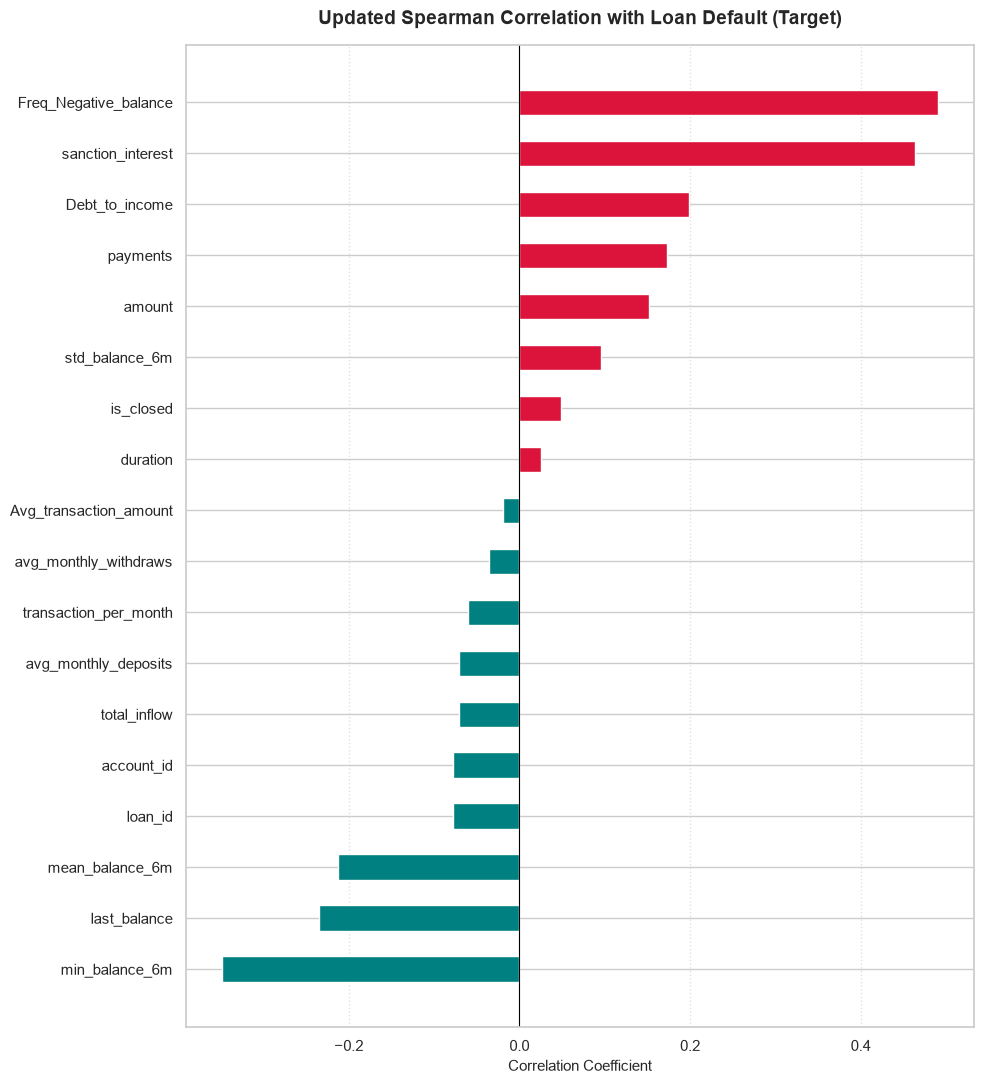

In [46]:

loan_with_trans = loan.merge(
    trans_agg.drop(columns=['account_id'], errors='ignore'),
    on='loan_id',
    how='left',
)

# 2. Define the target column (1 for Default/Bad loans: status B or D, 0 otherwise)
loan_with_trans['target'] = loan_with_trans['status'].isin(['B', 'D']).astype(
    int
)

# 3. Compute Spearman correlation for all numerical features with the target
spearman_corr = (
    loan_with_trans.corr(method='spearman', numeric_only=True)['target']
    .drop('target')
    .sort_values(ascending=True)  # Ascending so high positive correlations plot at the top
)

# 4. Color assignment: Teal (#008080) for negative, Crimson (#DC143C) for positive
colors = ['#008080' if val < 0 else '#DC143C' for val in spearman_corr.values]

# 5. Render horizontal bar chart
plt.figure(figsize=(10, 11))
plt.barh(spearman_corr.index, spearman_corr.values, color=colors, height=0.5)

plt.title(
    'Updated Spearman Correlation with Loan Default (Target)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Correlation Coefficient', fontsize=11)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()



In [47]:
# Convert keys to string for merging
trans_agg['loan_id'] = trans_agg['loan_id'].astype(str)
loan['loan_id'] = loan['loan_id'].astype(str)

# Join updated features to main loan table
loan_with_trans = loan.merge(
    trans_agg.drop(columns=['account_id'], errors='ignore'),
    on='loan_id',
    how='left',
)

# Set target flag
loan_with_trans['target'] = loan_with_trans['status'].isin(['B', 'D']).astype(
    int
)

# Compute correlations
trans_cols = [
    'min_balance_6m',
    'mean_balance_6m',
    'std_balance_6m',
    'total_inflow',
    'sanction_interest',
    'last_balance',
    'Freq_Negative_balance',
    'avg_monthly_withdraws',
    'avg_monthly_deposits',
    'Avg_transaction_amount',
    'transaction_per_month',
    'Debt_to_income',
]

correlations = (
    loan_with_trans[trans_cols + ['target']]
    .corr()['target']
    .drop('target')
    .sort_values(ascending=False)
)

print(correlations.round(4))

Freq_Negative_balance     0.2878
Debt_to_income            0.2774
sanction_interest         0.1940
std_balance_6m            0.1041
Avg_transaction_amount   -0.0185
avg_monthly_withdraws    -0.0389
avg_monthly_deposits     -0.0544
total_inflow             -0.0544
transaction_per_month    -0.0915
last_balance             -0.1959
mean_balance_6m          -0.2232
min_balance_6m           -0.3515
Name: target, dtype: float64


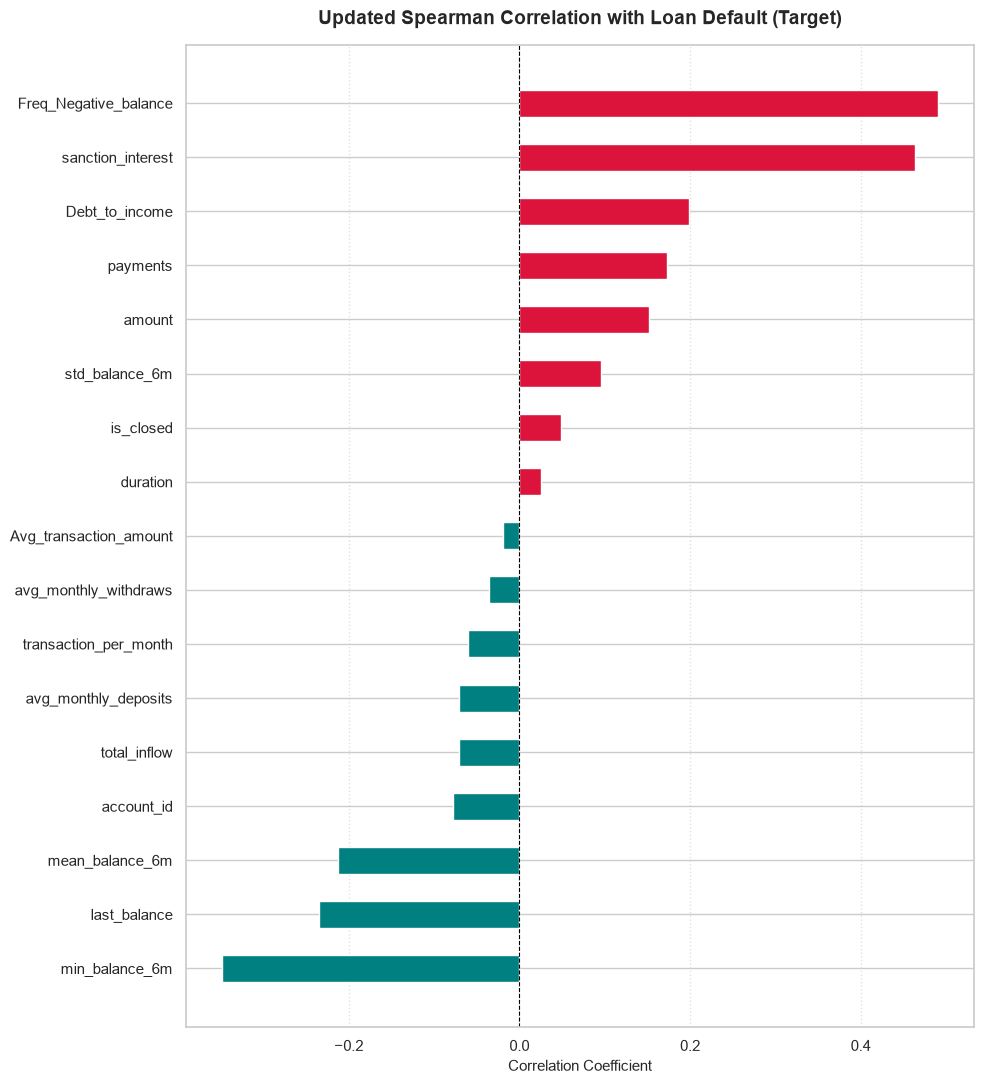

In [51]:

# 1. Compute Spearman correlations with the target column
# (Excluding the target itself)
spearman_corr = (
    loan_with_trans.corr(method='spearman', numeric_only=True)['target']
    .drop('target')
    .sort_values(ascending=True)  # Sort ascending so highest appears at the top of the horizontal bar chart
)

# 2. Set up colors based on positive/negative correlation values
colors = ['#008080' if val < 0 else '#DC143C' for val in spearman_corr.values]

# 3. Create the bar chart
plt.figure(figsize=(10, 11))
bars = plt.barh(spearman_corr.index, spearman_corr.values, color=colors, height=0.5)

# 4. Styling and labels
plt.title('Updated Spearman Correlation with Loan Default (Target)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Correlation Coefficient', fontsize=11)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')  # Zero reference line
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()